In [1]:
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import MinMaxScaler
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import json
import re

scaler_minmax = MinMaxScaler()
softmax_column = torch.nn.Softmax(dim=0)
prefix = 'Ġ'

c:\Users\user0\llm_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load stopwords
stopwords = []
with open('UGIR_stopwords.txt', "r") as f:
    for line in f:
        if line:
            stopwords.append(line.replace('\n', ''))

def get_equation_indices(text_tokens, phrase, prefix):
    text_tokens = [t.replace(prefix, '') for t in text_tokens]
    # print(text_tokens)

    phrase = phrase.replace(' ', '')
    phrase = phrase.replace('\n', 'Ċ')

    matched_indices = []
    matched_index = []
    target = phrase
    for i in range(len(text_tokens)):
        cur_token = text_tokens[i]
        sub_len = min(len(cur_token), len(target))
        if cur_token[:sub_len] == target[:sub_len]:
            matched_index.append(i)
            target = target[sub_len:]
            if len(target) == 0:
                matched_indices.append([matched_index[0], matched_index[-1] + 1])
                target = phrase
        else:
            matched_index = []
            target = phrase
            if cur_token[:sub_len].lower() == target[:sub_len]:
                matched_index.append(i)
                target = target[sub_len:]
                if len(target) == 0:
                    matched_indices.append([matched_index[0], matched_index[-1] + 1])
                    target = phrase

    return matched_indices


def get_phrase_indices(text_tokens, phrase, prefix):
    text_tokens = [t.replace(prefix, '') for t in text_tokens]
    # print(text_tokens)

    phrase = phrase.replace(' ', '')

    matched_indices = []
    matched_index = []
    target = phrase
    for i in range(len(text_tokens)):
        cur_token = text_tokens[i]
        sub_len = max(min(len(cur_token), len(phrase)),len(cur_token))
        if cur_token[:sub_len].lower() == target[:sub_len]:
            matched_index.append(i)
            target = target[sub_len:]
            if len(target) == 0:
                matched_indices.append([matched_index[0], matched_index[-1] + 1])
                target = phrase
        else:
            matched_index = []
            target = phrase
            if cur_token[:sub_len].lower() == target[:sub_len]:
                matched_index.append(i)
                target = target[sub_len:]
                if len(target) == 0:
                    matched_indices.append([matched_index[0], matched_index[-1] + 1])
                    target = phrase

    return matched_indices

def get_tokens_indices(text_tokens, phrase, prefix):
    text_tokens = [t.replace(prefix, '') for t in text_tokens]

    phrase = phrase.replace(' ', '')

    matched_indices = []
    matched_index = []
    target = phrase
    for i in range(len(text_tokens)):
        cur_token = text_tokens[i]
        sub_len = min(len(cur_token), len(phrase))
        if cur_token[:sub_len] == target[:sub_len]:
            matched_index.append(i)
            target = target[sub_len:]
            if len(target) == 0:
                matched_indices.append([matched_index[0], matched_index[-1] + 1])
                target = phrase
        else:
            matched_index = []
            target = phrase
            if cur_token[:sub_len].lower() == target[:sub_len]:
                matched_index.append(i)
                target = target[sub_len:]
                if len(target) == 0:
                    matched_indices.append([matched_index[0], matched_index[-1] + 1])
                    target = phrase

    return matched_indices

def get_all_indices(candidates_pos_dict, window_end):
    all_indices = []
    for phrase in candidates_pos_dict.values():
        for element in phrase:
            start_index = element[0]
            end_index = element[1]
            if(start_index>window_end):
                all_indices.extend(range(start_index, end_index))
    all_indices = sorted(all_indices)
    all_indices = list(dict.fromkeys(all_indices))

    return all_indices

In [ ]:
# Name of the pretrained or fine-tuned model to be integrated with CAS
# It can be a huggingface model or a local model path
# Examples: "./Agent_resources/Models/roberta_ds_all", "FacebookAI/roberta-base"
# The following code employs the fine-tuned model obtained from the previous notebook THE MODEL FINE-TUNING
model_name = "./Agent_resources/Models/final_finetuning"
tokenizer_sim = AutoTokenizer.from_pretrained("roberta-base")
model_sim = AutoModel.from_pretrained(model_name, output_attentions=True, output_hidden_states=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1820.76it/s]


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

model_sim.to(device)
model_sim.eval()

device: cuda


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

ID: 4eff0720836a198b6174eecf02cbfdbf
N pages: 28
Title: 第０回：授業の準備
Lecture Title: Session 0: Course Preparation


100%|██████████| 28/28 [00:50<00:00,  1.80s/it]


ID: 5a4be1fa34e62bb8a6ec6b91d2462f5a
N pages: 15
Title: 第７回：離散時間システム～線形時不変システム，差分方程式～
Lecture Title: Session 7: Discrete-Time Systems – Linear Time-Invariant Systems and Difference Equations


100%|██████████| 15/15 [00:26<00:00,  1.78s/it]


ID: 69f62956429865909921fa916d61c1f8
N pages: 19
Title: 第５回：離散時間信号とZ変換
Lecture Title: Lecture 5: Discrete-Time Signals and the Z-Transform


...

100%|██████████| 11/11 [00:12<00:00,  1.16s/it]


ID: cceff8faa855336ad53b3325914caea2
N pages: 17
Title: 第４回：連続時間信号の標本化
Lecture Title: Lecture 4: Sampling of Continuous-Time Signals


100%|██████████| 17/17 [00:31<00:00,  1.83s/it]


ID: fb642b781020b2aaeb1a7cee29acc915
N pages: 17
Title: 第８回：離散時間システム～周波数特性～
Lecture Title: Lecture 8: Discrete-Time Systems – Frequency Characteristics –


100%|██████████| 17/17 [00:28<00:00,  1.66s/it]


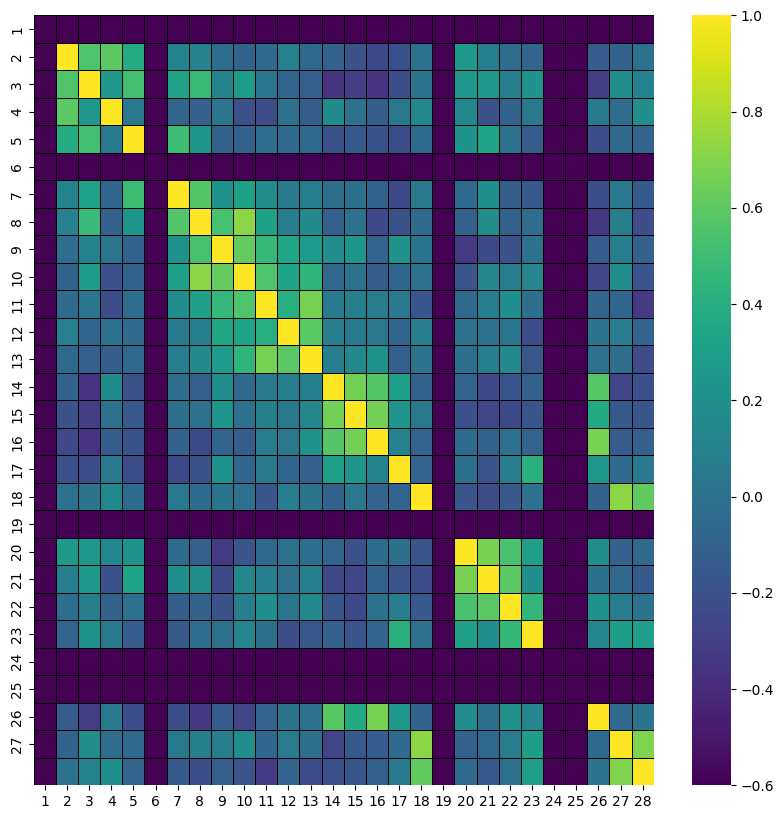

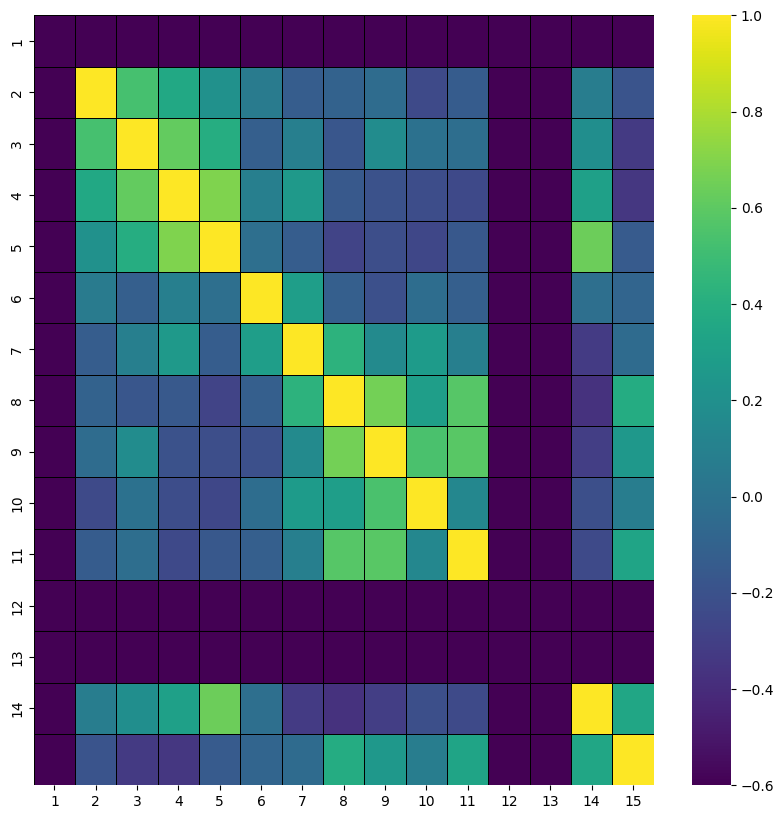

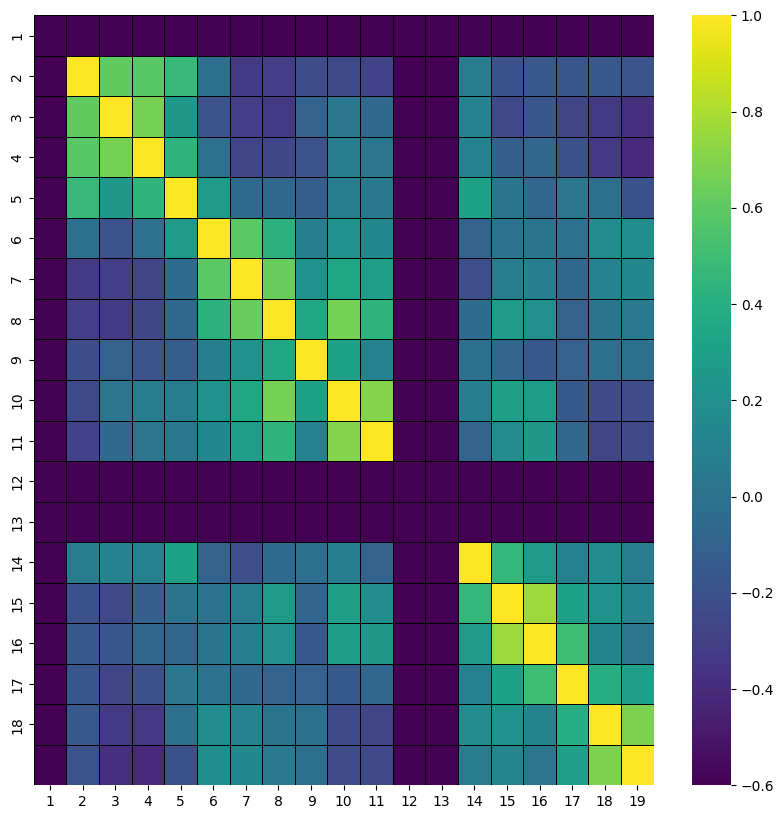

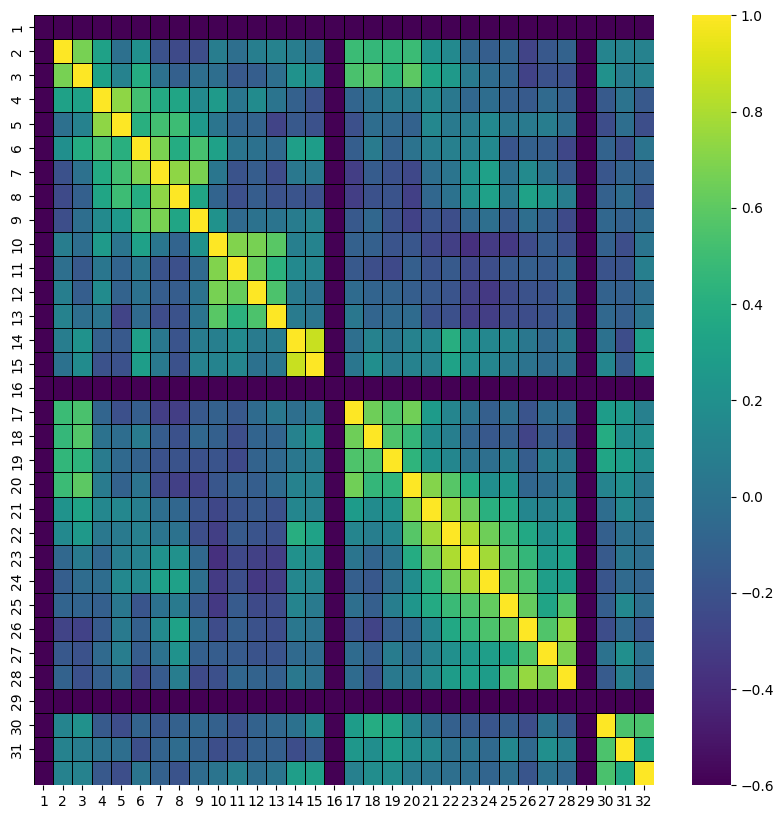

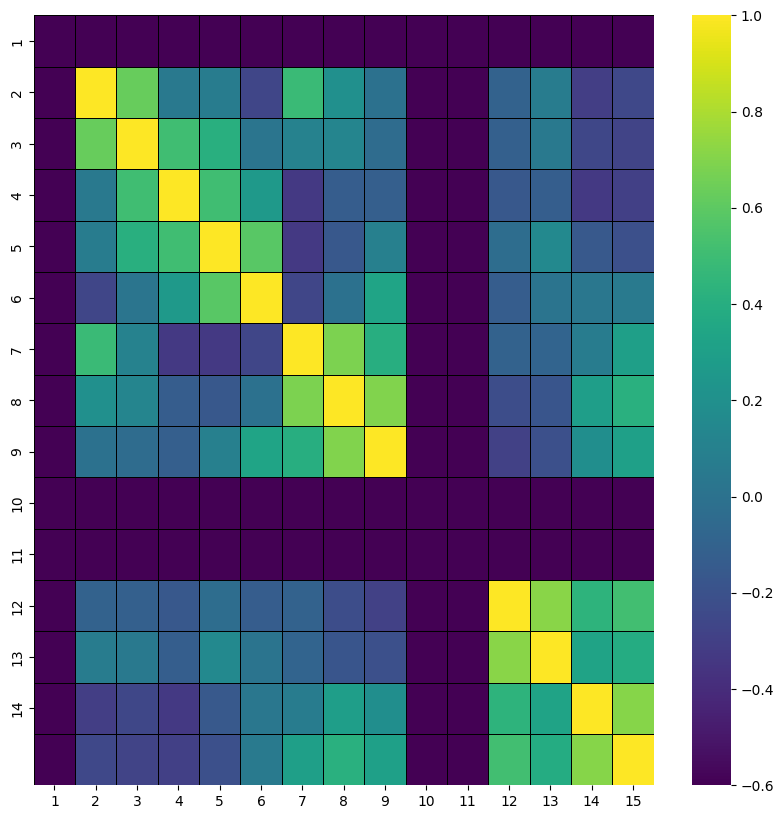

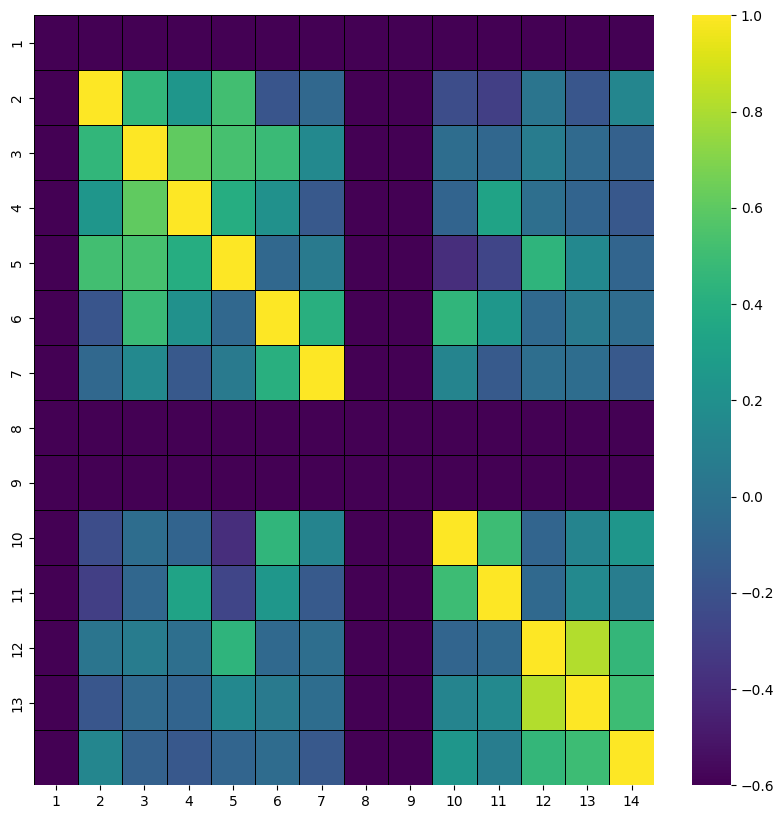

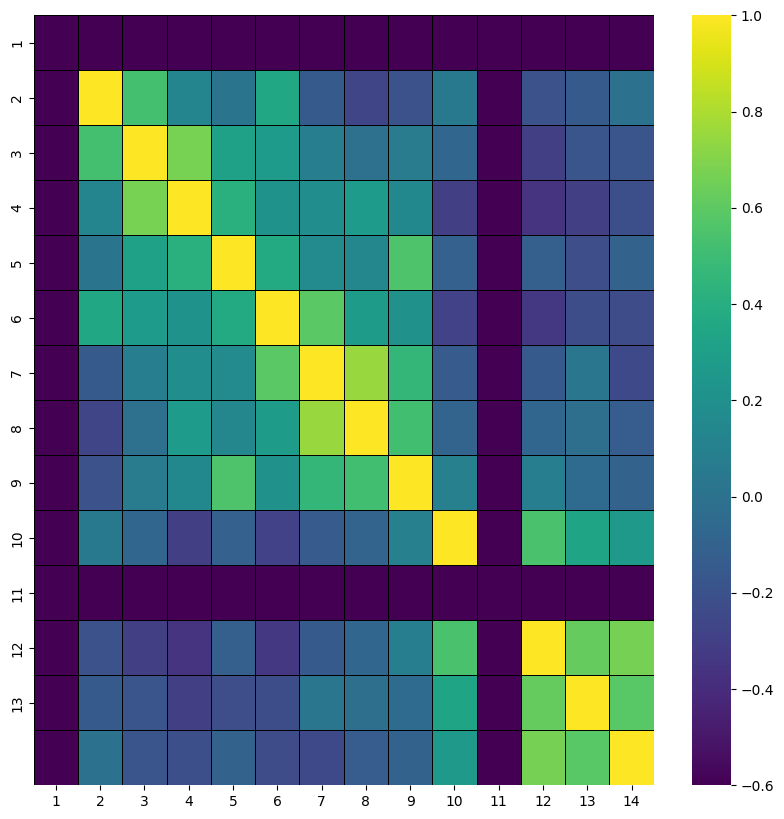

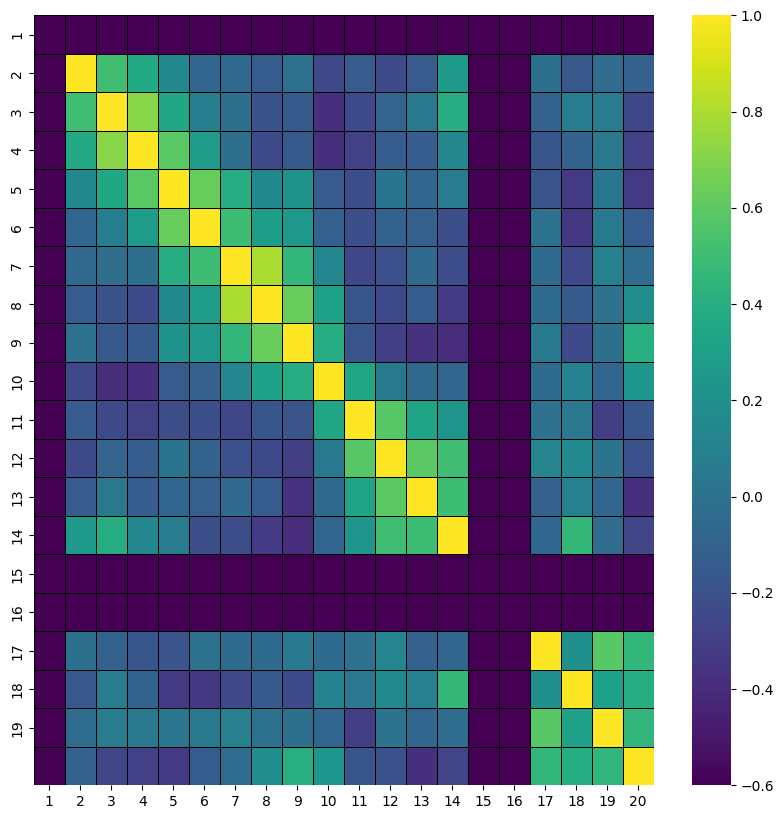

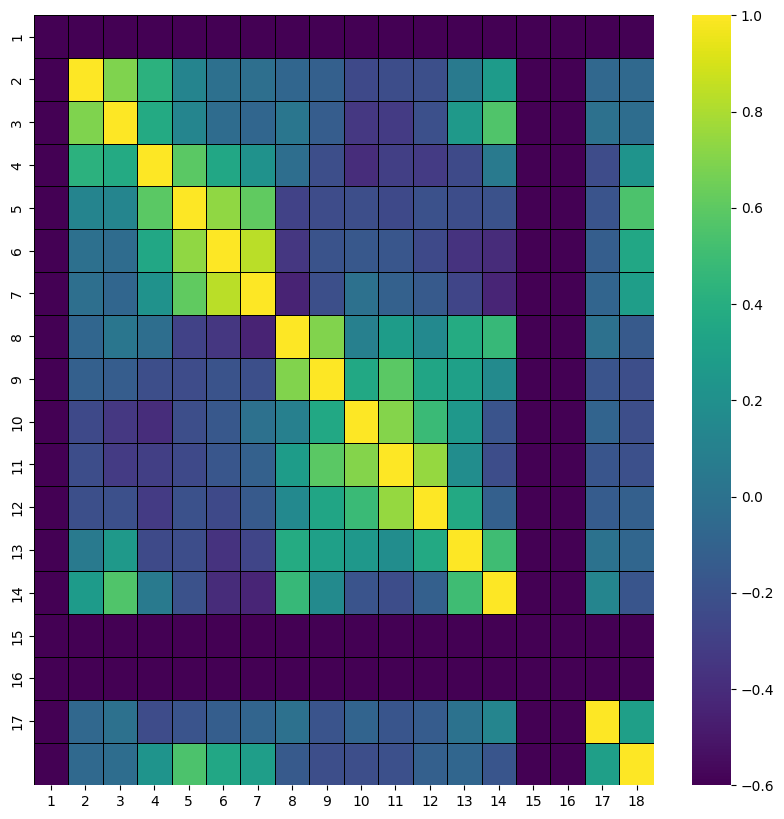

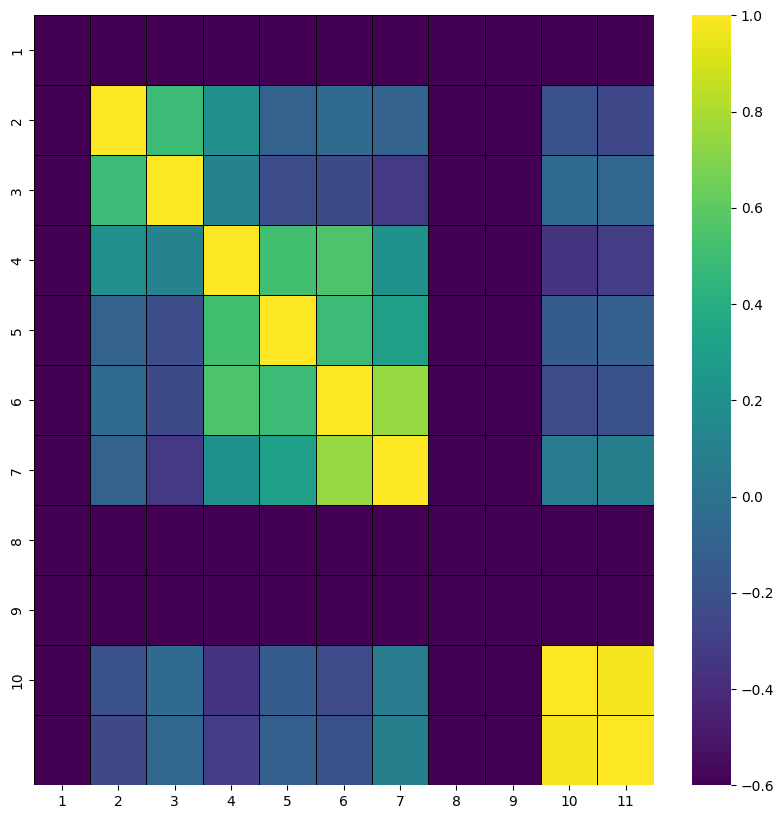

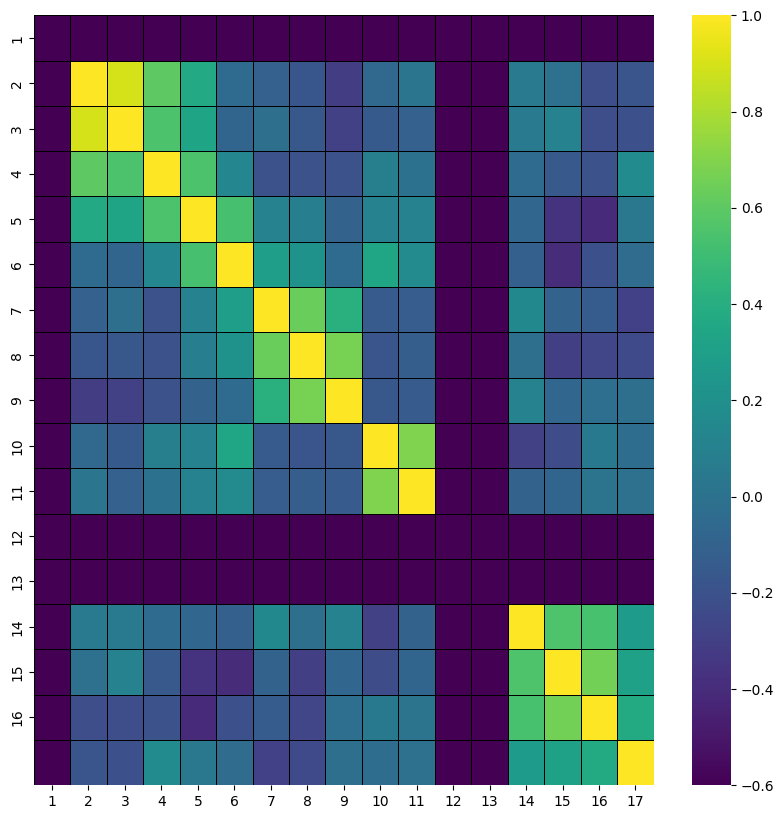

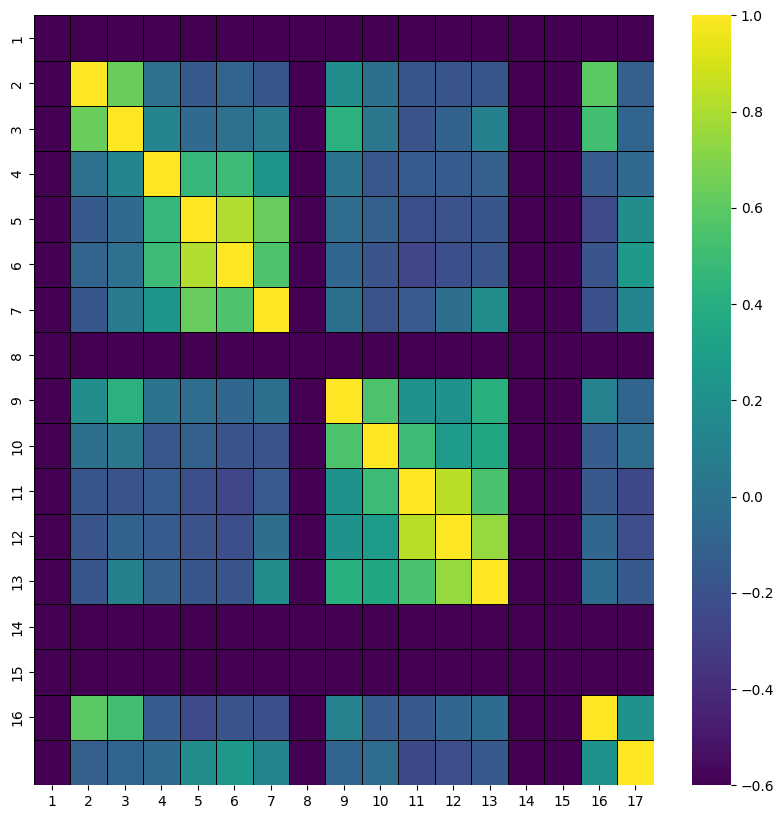

In [ ]:
# This code works for the course "Digital Signal Theory" from Kyushu University used in the experiments
# For a new course, you need to include here the information about the lecture materials included in the course (contentsid)
# the number of pages of each material (pages) and the name of the corresponding class (title)
course_id = 207
course_materials = pd.read_csv("./pid{}_material_info.csv".format(course_id))[["contentsid","pages","title"]]

for n_material in range(course_materials.shape[0]):
    material_id = course_materials["contentsid"][n_material]
    max_pages = course_materials["pages"][n_material]
    title = course_materials["title"][n_material]

    # Metadata generated in the previous notebook EXTRACT_TEXT_AND _LABELS
    with open("./Agent_resources/Titles/pid{}_{}_title.txt".format(course_id,material_id), "r", encoding="utf-8") as f:
        lecture_title = f.read()
        
    print("ID: {}".format(material_id))
    print("N pages: {}".format(max_pages))
    print("Title: {}".format(title))
    print("Lecture Title: {}".format(lecture_title))

    non_informative = ["TITLE_SLIDE","AGENDA_SLIDE","HEADER_SLIDE","CONCLUSION_SLIDE"]
    slide_types = []
    # Metadata generated in the previous notebook EXTRACT_TEXT_AND _LABELS
    with open(f"./Agent_resources/Slide_types/pid_{course_id}_{material_id}_slide_types.txt", "r") as file:
        for line in file:
            slide_types.append(line.strip())

    slide_filtered = []
    eq_pattern = r'\[\[(.*?)\]\]'
    corr_result = np.eye(max_pages,max_pages)

    for i in tqdm(range(1,max_pages+1)):
        # Metadata generated in the previous notebook EXTRACT_TITLE_AND_CONTENTS
        with open("./Agent_resources/TitleC_versions/pid{}_{}_title_4_p{}.txt".format(course_id,material_id,i), "r", encoding="utf-8") as f:
            crrn_title = f.read()
        with open("./Agent_resources/TitleC_versions/pid{}_{}_body_4_p{}.txt".format(course_id,material_id,i), "r", encoding="utf-8") as f:
            crrn_body = f.read()
        
        if slide_types[i-1] in non_informative:
            slide_filtered.append(i-1)
            corr_result[i-1,:] = -0.6
            corr_result[:,i-1] = -0.6
        else:
            test_txt_1 = crrn_title + ":\n" + crrn_body

            for j in range(i+1,max_pages+1):
                if not slide_types[j-1] in non_informative:
                    # Metadata generated in the previous notebook EXTRACT_TITLE_AND_CONTENTS
                    with open("./Agent_resources/TitleC_versions/pid{}_{}_title_4_p{}.txt".format(course_id,material_id,j), "r", encoding="utf-8") as f:
                        crrn_title = f.read()
                    with open("./Agent_resources/TitleC_versions/pid{}_{}_body_4_p{}.txt".format(course_id,material_id,j), "r", encoding="utf-8") as f:
                        crrn_body = f.read()
                    test_txt_2 = crrn_title + ":\n" + crrn_body

                    with torch.no_grad():
                        s_tokens = tokenizer_sim(test_txt_1, return_tensors='pt', truncation=True, max_length=512)
                        s_outputs = model_sim(**s_tokens.to(device))
                        s_tokens_read = tokenizer_sim.convert_ids_to_tokens(s_tokens['input_ids'].squeeze(0))
                        embeddings = s_outputs.hidden_states[-1][0]

                        stopword_indices = {}
                        for stpw in stopwords:
                            matched_indices = get_phrase_indices(s_tokens_read, stpw, prefix)
                            if len(matched_indices) == 0:
                                continue
                            stopword_indices[stpw] = matched_indices
                        all_stopwords = get_all_indices(stopword_indices,0)

                        equation_indices = {}
                        equations = re.findall(eq_pattern, test_txt_1, flags=re.DOTALL)
                        equations = list(set(equations))
                        for equ in equations:
                            matched_indices = get_equation_indices(s_tokens_read, equ, prefix)
                            if len(matched_indices) == 0:
                                continue
                            equation_indices[equ] = matched_indices
                        all_equations = get_all_indices(equation_indices,0)

                        special_stopword_indices = {}
                        special_stopwords = [".",":",",","-","Ċ",".Ċ","ĊĊ",".ĊĊ","*","*,","*.","),","[[","]","]."]
                        for stpw in special_stopwords:
                            matched_indices = get_tokens_indices(s_tokens_read, stpw, prefix)
                            if len(matched_indices) == 0:
                                continue
                            special_stopword_indices[stpw] = matched_indices
                        all_s_stopwords = get_all_indices(special_stopword_indices,0)

                        non_inform_1 = list(set(all_stopwords)|set(all_equations)|set(all_s_stopwords)|set([0,-1]))

                        s_tokens_2 = tokenizer_sim(test_txt_2, return_tensors='pt', truncation=True, max_length=512)
                        s_outputs_2 = model_sim(**s_tokens_2.to(device))
                        s_tokens_read_2 = tokenizer_sim.convert_ids_to_tokens(s_tokens_2['input_ids'].squeeze(0))
                        embeddings_2 = s_outputs_2.hidden_states[-1][0]

                        stopword_indices_2 = {}
                        for stpw in stopwords:
                            matched_indices = get_phrase_indices(s_tokens_read_2, stpw, prefix)
                            if len(matched_indices) == 0:
                                continue
                            stopword_indices_2[stpw] = matched_indices
                        all_stopwords_2 = get_all_indices(stopword_indices_2,0)

                        equation_indices_2 = {}
                        equations_2 = re.findall(eq_pattern, test_txt_2, flags=re.DOTALL)
                        equations_2 = list(set(equations_2))
                        for equ in equations_2:
                            matched_indices = get_equation_indices(s_tokens_read_2, equ, prefix)
                            if len(matched_indices) == 0:
                                continue
                            equation_indices_2[equ] = matched_indices
                        all_equations_2 = get_all_indices(equation_indices_2,0)

                        special_stopword_indices_2 = {}
                        special_stopwords = [".",":",",","-","Ċ",".Ċ","ĊĊ",".ĊĊ","*","*,","*.","),","[[","]","]."]
                        for stpw in special_stopwords:
                            matched_indices = get_tokens_indices(s_tokens_read_2, stpw, prefix)
                            if len(matched_indices) == 0:
                                continue
                            special_stopword_indices_2[stpw] = matched_indices
                        all_s_stopwords_2 = get_all_indices(special_stopword_indices_2,0)

                        non_inform_2 = list(set(all_stopwords_2)|set(all_equations_2)|set(all_s_stopwords_2)|set([0,-1]))
                    
                    heatmap_cross = embeddings_2@embeddings.T
                    to_display = heatmap_cross.cpu()
                    to_display[:,non_inform_1] = 0
                    to_display[non_inform_2,:] = 0

                    scores = to_display.sum(0).cpu()
                    indices_cero = scores == 0.0
                    datos_no_cero = scores[~indices_cero].reshape(-1, 1)
                    scaler_minmax.fit(datos_no_cero)
                    scores = scaler_minmax.transform(scores.reshape(-1, 1))
                    scores[indices_cero] = 0

                    scores_2 = to_display.sum(1).cpu()
                    indices_cero = scores_2 == 0.0
                    datos_no_cero = scores_2[~indices_cero].reshape(-1, 1)
                    scaler_minmax.fit(datos_no_cero)
                    scores_2 = scaler_minmax.transform(scores_2.reshape(-1, 1))
                    scores_2[indices_cero] = 0

                    all_attentions = s_outputs.attentions
                    # ATTENTION-SEEKER
                    len_t_tokens = all_attentions[0].squeeze(0)[0].shape[0]
                    all_indices_tensor = torch.arange(len_t_tokens)
                    mask = torch.isin(all_indices_tensor, torch.tensor(non_inform_1)).to(device).logical_not()
                    # LHC-SEEKER
                    f_att_scores = torch.tensor(scores,dtype=torch.float32).to(device).squeeze()
                    # NEW ATTENTION MEASSUREMENT
                    attentions = torch.zeros(len_t_tokens).to(device)
                    for layer in range(len(all_attentions)):
                        for head in range(12):
                            crrn_att_map = all_attentions[layer].squeeze(0)[head].clone()
                            lh_weight = f_att_scores
                            attentions += lh_weight.mean(0)*torch.matmul(lh_weight,crrn_att_map)
                    att_scores = attentions
                    att_scores[0] = 0

                    for st in all_stopwords:
                        att_scores[st] = 0
                    for st in all_equations:
                        att_scores[st] = 0
                    for st in all_s_stopwords:
                        att_scores[st] = 0
                    att_scores[-1] = 0

                    all_attentions_2 = s_outputs_2.attentions
                    # ATTENTION-SEEKER
                    len_t_tokens_2 = all_attentions_2[0].squeeze(0)[0].shape[0]
                    all_indices_tensor_2 = torch.arange(len_t_tokens_2)
                    mask = torch.isin(all_indices_tensor_2, torch.tensor(non_inform_2)).to(device).logical_not()
                    # LHC-SEEKER
                    f_att_scores = torch.tensor(scores_2,dtype=torch.float32).to(device).squeeze()
                    # NEW ATTENTION MEASSUREMENT
                    attentions_2 = torch.zeros(len_t_tokens_2).to(device)
                    for layer in range(len(all_attentions_2)):
                        for head in range(12):
                            crrn_att_map = all_attentions_2[layer].squeeze(0)[head].clone()
                            lh_weight = f_att_scores
                            attentions_2 += lh_weight.mean(0)*torch.matmul(lh_weight,crrn_att_map)
                    att_scores_2 = attentions_2
                    att_scores_2[0] = 0

                    for st in all_stopwords_2:
                        att_scores_2[st] = 0
                    for st in all_equations_2:
                        att_scores_2[st] = 0
                    for st in all_s_stopwords_2:
                        att_scores_2[st] = 0
                    att_scores_2[-1] = 0

                    embedd_slide_1 = att_scores@embeddings
                    embedd_slide_1 = F.normalize(embedd_slide_1, p=2, dim=0)
                    embedd_slide_2 = att_scores_2@embeddings_2
                    embedd_slide_2 = F.normalize(embedd_slide_2, p=2, dim=0)
                    cos_sim = embedd_slide_1@embedd_slide_2

                    corr_result[i-1,j-1] = cos_sim.cpu().item()
                    corr_result[j-1,i-1] = cos_sim.cpu().item()

    minscale = np.floor(np.min(np.where(corr_result == 0, np.inf, corr_result))* 10) / 10

    # Create the heatmap
    plt.figure(figsize=[10,10])
    ax = sns.heatmap(corr_result,xticklabels=np.arange(1,max_pages+1),yticklabels=np.arange(1,max_pages),cmap=plt.get_cmap("viridis"),linewidth=.5,linecolor="black",vmin=minscale)

    # Display the plot
    plt.savefig(f"./Agent_resources/Similarities/finetuning_seeker_{course_id}_{material_id}.png",dpi=300,bbox_inches="tight")
    np.save(f'./Agent_resources/Similarities/finetuning_seeker_{course_id}_{material_id}.npy', corr_result)